# MNIST Image Classification with a Multilayer Perceptron (MLP) in PyTorch

This notebook demonstrates how to build and train a simple Multilayer Perceptron (MLP) neural network using PyTorch to classify handwritten digits from the MNIST dataset. It covers essential steps from data loading and preprocessing to model definition, training, and evaluation.

## Table of Contents

1.  [Setting up the Environment and Loading Data](#section1)
    *   1.1 Imports
    *   1.2 Device Specification
    *   1.2 Data Loading & Transformations
    *   1.3 Exploring the Dataset Structure
    *   1.4 Preparing Data with DataLoaders
2.  [Defining the Model Architecture](#section2)
    *   2.1 Multilayer Perceptron (MLP) Class
    *   2.2 Model Instantiation and Parameter Count
3.  [Loss Function and Optimizer](#section3)
    *   3.1 Loss Function (`nn.CrossEntropyLoss`)
    *   3.2 Optimizer (`torch.optim.Adam`)
4.  [Implementing the Training Loop](#section5)
    *   5.1 Epoch and Batch Processing
    *   5.2 Tracking Metrics
5.  [Performance Evaluation](#section6)
    *   6.1 Visualizing Training Progress
    *   6.2 Final Test Set Evaluation
    *   6.3 Confusion Matrix Analysis
6.  [Key PyTorch Training Concepts (Prerequisites)](#section4)
    *   4.1 Reshaping Inputs for the MLP (`.view()`)
    *   4.2 Understanding Model Outputs (`.data` vs. `.detach()` vs. `torch.no_grad()`)
    *   4.3 Converting Model Probabilities to Predicted Labels
    *   4.4 Extracting Scalar Values (`.item()`)
    *   4.5 The Core Training Loop (`optimizer.zero_grad()`, `loss.backward()`, `optimizer.step()`)
    *   4.6 Batch-Level vs. Epoch-Level Metrics
    *   4.7 Moving Tensors to CPU/GPU (Device Management)

<a id='section1'></a>
## 1. Setting up the Environment and Loading Data


### 1.1 Imports

This section begins by importing all necessary libraries for our MNIST classification task. We use:

-   `torch`, `torch.nn`, `torch.nn.functional`: The core PyTorch library for building neural networks and performing tensor operations.
-   `torch.utils.data.DataLoader`: For efficient batching and loading of datasets.
-   `torchvision.datasets`, `torchvision.transforms`: To easily download and apply transformations to the MNIST dataset.
-   `numpy`, `pandas`, `sklearn.metrics`: For numerical operations, data handling (though less used directly in this PyTorch context), and performance evaluation (e.g., confusion matrix).
-   `matplotlib.pyplot`: For plotting and visualizing images and training metrics.
-   `%matplotlib inline`: A magic command for Jupyter/Colab to display plots directly within the notebook.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
%matplotlib inline

### 1.2 Device

Why is Defining the Device (CPU/GPU) Important?

In deep learning, the choice of computing device (CPU or GPU) significantly impacts training speed and efficiency. GPUs are highly parallel processors designed to handle the massive matrix operations inherent in neural network computations much faster than CPUs.

-   `torch.cuda.is_available()`: This function checks if a CUDA-enabled GPU is present and accessible to PyTorch.
-   `device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')`: This line intelligently sets the `device` variable. If a GPU is found, it assigns `'cuda'` (PyTorch's term for GPU computing); otherwise, it defaults to `'cpu'`. This makes your code portable, as it will run on a GPU if available, and gracefully fall back to the CPU if not.

**Importance:**
1.  **Performance**: Leveraging a GPU can reduce training times from hours or days to minutes, especially for larger models and datasets.
2.  **Scalability**: For complex models, CPU memory might not be sufficient, while GPUs often have dedicated, faster memory.
3.  **Reproducibility**: Explicitly defining the device ensures that if your code is run on different machines (some with GPUs, some without), it behaves predictably and uses the designated hardware.

Once the `device` is set, you must explicitly move your models and data to this device using `.to(device)` for computations to occur on the chosen hardware.

In [2]:
# Determine if GPU is available and set the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


#### When to move Tensors from GPU to CPU (and why):

While keeping data on the GPU is generally preferred for computational speed, there are specific situations where you *must* or *should* move tensors from the GPU back to the CPU, even during inference (testing/validation) when no gradients are being computed:

1.  **GPU Memory Constraints**: If your GPU has limited memory and you're processing very large models or batches, you might need to strategically move some tensors to the CPU to free up GPU memory. This is less about speed and more about feasibility.

2.  **CPU-Bound Operations/External Libraries**: Many Python libraries, especially for data manipulation, visualization, or specific statistical tests (e.g., `numpy`, `matplotlib`, `sklearn`), are designed to work with CPU-based data structures. If you need to:
    *   Convert a PyTorch tensor to a NumPy array (`.numpy()` method).
    *   Plot data using `matplotlib` (which typically expects CPU tensors or NumPy arrays).
    *   Perform operations with `scikit-learn` functions (like `confusion_matrix`, as seen in this notebook).
    *   Extract a single Python scalar value from a tensor (`.item()` method).

    In these cases, the tensor *must* be on the CPU before performing the operation. Attempting to call `.numpy()` or `.item()` on a GPU tensor will raise an error.

3.  **Logging and Monitoring (Scalar Values)**: When you extract metrics like loss or accuracy per batch or epoch for logging, plotting, or printing, you typically use `.item()` to get the Python scalar. As mentioned above, `.item()` requires the tensor to be on the CPU.

4.  **Transfer Overhead**: It's important to remember that moving data between CPU and GPU incurs a communication overhead. Therefore, you should only move data when necessary. For instance, if you have a series of GPU-accelerated operations, it's best to perform them all on the GPU and only transfer the final result back to the CPU if needed for further analysis or visualization.

**In summary, for computational speed, keep data on the GPU as much as possible. Only transfer to CPU when you need to interact with CPU-only libraries, extract Python scalar values, or when absolutely necessary due to memory constraints.**

### 1.3 Data Loading & Transformations

The MNIST dataset consists of handwritten digit images. Before loading, we define a transformation to convert the images into PyTorch tensors. This is a crucial step as PyTorch models operate on tensors.

-   `transforms.ToTensor()`: Converts a PIL Image or NumPy array to a PyTorch `FloatTensor` and scales the pixel intensity values to the range `[0.0, 1.0]`.

We then download and load the MNIST training and test datasets using `datasets.MNIST`:

-   `root='../Data'`: Specifies the directory where the dataset will be stored.
-   `train=True/False`: Indicates whether to load the training or testing split of the dataset.
-   `download=True`: Downloads the dataset if it's not already available locally.
-   `transform=transform`: Applies the transformation to each image as it's loaded.

In [3]:
# MNIST Image ---> Tensor
transform = transforms.ToTensor()

In [4]:
#you can specify the path to save the dataset in using `root=`
train_data = datasets.MNIST(root='../Data', train=True, download=True, transform=transform)

test_data = datasets.MNIST(root='../Data', train=False, download=True, transform=transform)

print(train_data)
print(test_data)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 477kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.51MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.1MB/s]

Dataset MNIST
    Number of datapoints: 60000
    Root location: ../Data
    Split: Train
    StandardTransform
Transform: ToTensor()
Dataset MNIST
    Number of datapoints: 10000
    Root location: ../Data
    Split: Test
    StandardTransform
Transform: ToTensor()


### 1.4 Exploring the Dataset Structure

The `train_data` and `test_data` objects are instances of `torchvision.datasets.MNIST`, which inherit from PyTorch's `Dataset` class. This means we can access individual data points using indexing, similar to a list.

-   `train_data[0]`: Retrieves the first sample from the training dataset. Each sample is a tuple containing an image (as a PyTorch tensor) and its corresponding label (an integer).
-   `image.shape`: For MNIST, each image tensor has a shape of `(1, 28, 28)`. The `1` represents a single color channel (grayscale), and `28x28` is the height and width of the image.
-   `plt.imshow(image.reshape((28, 28)), cmap="gray")`: We reshape the `(1, 28, 28)` image tensor to `(28, 28)` to correctly display it using Matplotlib's `imshow` function. The `cmap="gray"` argument ensures it's displayed in grayscale.

In [5]:
type(train_data)

torchvision.datasets.mnist.MNIST

In [6]:
train_data[0]

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

so this torchvision.datasets.mnist.MNIST is a bunch of tensors organized together

In [7]:
type(train_data[0])

tuple

it is a tuple of (image, label); image is 28*28 and label is an int

In [8]:
image, label = train_data[0]
print(image.shape) # (1, 28, 28); 1 because it is a gray scale image
print(label)

torch.Size([1, 28, 28])
5


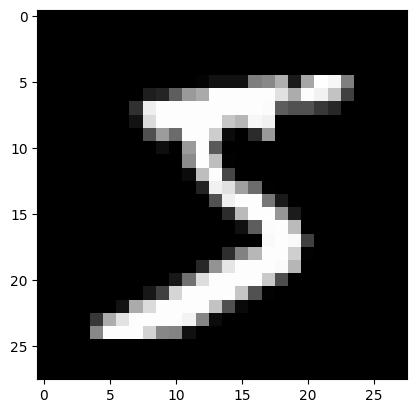

In [9]:
plt.imshow(image.reshape((28, 28)), cmap="gray") # reverse colormap of gray is "gist_yarg"

### 1.5 Preparing Data with DataLoaders

While `Dataset` objects allow access to individual samples, for training neural networks, it's far more efficient to process data in mini-batches. PyTorch's `DataLoader` provides this functionality.

-   `DataLoader(dataset, batch_size, shuffle)`:
    -   `dataset`: The `Dataset` object (e.g., `train_data` or `test_data`).
    -   `batch_size`: The number of samples to include in each batch. For training, a `batch_size` of `100` is used, while for testing, a larger `batch_size` of `500` is often acceptable as backpropagation is not performed.
    -   `shuffle=True`: For the training data, we shuffle the samples at the beginning of each epoch to ensure the model sees data in a different order each time, which helps prevent overfitting and improves generalization. For the test data, `shuffle=False` is typically used as the order doesn't affect evaluation metrics.


In [10]:
torch.manual_seed(101) #for reproducibility: ensuring that we
# always have the sample batches
batch_size_train = 100
train_loader = DataLoader(train_data, batch_size=batch_size_train, shuffle=True)
# the reason why we want to shuffle is that sometimes the certtain datasets are organized or sorted
# so maybe here all images of 0 are together. by shuffling
# we kinda prevent this
batch_size_test = 500
test_loader = DataLoader(test_data, batch_size=batch_size_test, shuffle=False)
# for test set we can use higher batch-sizes because the thing is that
# the model just do a forward feeding and is light in computation
# than training step with backpropagations

-   **Iterating through a DataLoader**:
    -   `iter(train_loader)`: Converts the `DataLoader` into an iterator.
    -   `next(train_iter)`: Retrieves the next batch of images and labels.

-   `first_batch_images.shape`: After loading a batch, the image tensor will have a shape like `(batch_size, num_color_channels, height, width)`, e.g., `(100, 1, 28, 28)` for the training data.

-   `make_grid` (from `torchvision.utils`): This utility function helps visualize multiple images from a batch by arranging them in a grid. We then transpose the dimensions of the grid (`np.transpose(im.numpy(), (1, 2, 0))`) to fit Matplotlib's `imshow` expectation (Height, Width, Channels).

Shape of images in the first batch: torch.Size([100, 1, 28, 28])
Shape of labels in the first batch: torch.Size([100])
First label in the batch: 7


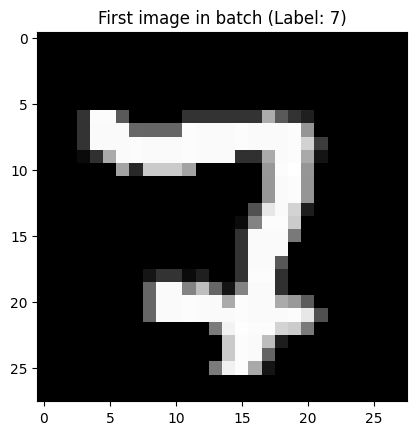

In [11]:
train_iter = iter(train_loader)
first_batch_images, first_batch_labels = next(train_iter) #the first batch in the train dataloader

print(f"Shape of images in the first batch: {first_batch_images.shape}")
print(f"Shape of labels in the first batch: {first_batch_labels.shape}")

# You can also display the first image and its label from this batch
print(f"First label in the batch: {first_batch_labels[0].item()}")
plt.imshow(first_batch_images[0].reshape((28, 28)), cmap="gray")
plt.title(f"First image in batch (Label: {first_batch_labels[0].item()})")
plt.show()

Labels:  [   7    2    3    5    8    5    3    6    9    9    1    3]


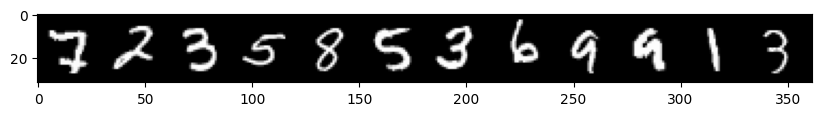

In [12]:
from torchvision.utils import make_grid
np.set_printoptions(formatter=dict(int=lambda x: f'{x:4}')) # formatting

# print the first 12 labels
print('Labels: ', first_batch_labels[:12].numpy())

# print the first 12 images out of 100 total in a batch
im = make_grid(first_batch_images[:12], nrow=12) # the default nrow is 8
plt.figure(figsize=(10, 4))
plt.imshow(np.transpose(im.numpy(), (1, 2, 0))) # we need to transpose the images from CWH to WHC
# this format is suitable for matplotlib

# 2. Defining the Model Architecture

### 2.1 Multilayer Perceptron (MLP) Class

Our neural network is defined as a `MultilayerPerceptron` class, which inherits from PyTorch's `nn.Module`. This inheritance is crucial as it provides the foundation for all neural network modules in PyTorch, automatically handling parameter tracking and providing utility methods.

#### `__init__(self, in_sz=784, out_sz=10, layers=[120, 84])`

The constructor (`__init__`) initializes the layers of our MLP:

-   `in_sz` (input size): The number of features in the input layer. For MNIST `28x28` images, this is `784` (flattened image). Default is `784`.
-   `out_sz` (output size): The number of output classes. For MNIST, there are `10` digits (0-9), so `out_sz` is `10`. Default is `10`.
-   `layers`: A list defining the number of neurons in the hidden layers. By default, `[120, 84]` means the first hidden layer has 120 neurons and the second has 84.

Inside `__init__`:

-   `super().__init__()`: Calls the constructor of the parent `nn.Module` class, which is essential for PyTorch module functionality.
-   `self.fc1 = nn.Linear(in_sz, layers[0])`: Defines the first fully connected (linear) layer. It takes the input of `in_sz` features and outputs `layers[0]` features.
-   `self.fc2 = nn.Linear(layers[0], layers[1])`: Defines the second fully connected layer, taking `layers[0]` features as input and outputting `layers[1]` features.
-   `self.fc3 = nn.Linear(layers[1], out_sz)`: Defines the output layer, taking `layers[1]` features and outputting `out_sz` features (the scores for each of the 10 classes).

#### `forward(self, x)`

The `forward` method defines the forward pass of the network, i.e., how data flows through the layers from input to output:

-   `x`: The input tensor to the network.
-   `x = F.relu(self.fc1(x))`: The input `x` first passes through `self.fc1`. The output of this layer is then passed through the Rectified Linear Unit (`ReLU`) activation function (`F.relu`). ReLU introduces non-linearity, allowing the network to learn complex patterns.
-   `x = F.relu(self.fc2(x))`: The output of the first hidden layer is passed through `self.fc2` and then another ReLU activation.
-   `x = self.fc3(x)`: The output of the second hidden layer is passed through the final output layer `self.fc3`.
-   `return x`: The model now returns the raw outputs (logits) from the final layer directly. This is because `nn.CrossEntropyLoss`, which we use as our loss function, internally applies `LogSoftmax` for numerical stability. Returning raw logits prevents applying `LogSoftmax` twice and is the recommended practice for efficiency and numerical stability.

In [13]:
class MultilayerPerceptron(nn.Module):
    # initialization
    def __init__(self, in_sz=784, out_sz=10, layers=[120, 84]):
        super().__init__()

        self.fc1 = nn.Linear(in_sz, layers[0])
        self.fc2 = nn.Linear(layers[0], layers[1])
        self.fc3 = nn.Linear(layers[1], out_sz)

    def forward(self, x):

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x # Return raw logits for nn.CrossEntropyLoss

### 2.2 Model Instantiation and Parameter Count

After defining our `MultilayerPerceptron` class, we need to instantiate it to create an actual model object. We also examine its structure and the total number of trainable parameters.

-   `torch.manual_seed(101)`: This sets the random seed for PyTorch, ensuring that the model's initial weights are the same every time the code is run. This is crucial for reproducibility, especially when debugging or comparing different model configurations.

-   `model = MultilayerPerceptron()`: This line creates an instance of our neural network. By default, it will use `in_sz=784`, `out_sz=10`, and `layers=[120, 84]` as defined in the `__init__` method.

-   `print(model)`: Displaying the model object prints a summary of its layers, including the input and output sizes and the activation functions used, providing a quick overview of the network architecture.


In [14]:
torch.manual_seed(101) # for reproducibility, to get the same random initialization

model = MultilayerPerceptron()
model.to(device) # Move the model to the selected device
model

MultilayerPerceptron(
  (fc1): Linear(in_features=784, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

-   **Counting Parameters**:
    -   `for param in model.parameters()`: We iterate through all the learnable parameters of the model (weights and biases). Each `param` is a PyTorch tensor.
    -   `param.numel()`: This method returns the total number of elements (i.e., scalar values) in the parameter tensor. By summing these up, we can determine the total number of weights and biases that the model needs to learn.
    -   The output shows the number of parameters for each layer's weights and biases. For example, `94080` comes from `(784 input features * 120 neurons in fc1)`. The `120` after that is the bias for `fc1`. This sum gives us insight into the model's complexity and memory footprint.

In [15]:
for param in model.parameters():
    print(param.numel())

94080
120
10080
84
840
10


## 3. Loss Function and Optimizer

To train our neural network, we need two fundamental components: a **Loss Function** to quantify the error between our model's predictions and the true labels, and an **Optimizer** to adjust the model's parameters in the direction that minimizes this loss.

### 3.1 Loss Function (`nn.CrossEntropyLoss`)

-   `criterion = nn.CrossEntropyLoss()`: We initialize `nn.CrossEntropyLoss` as our loss function. This is a common and highly effective loss function for multi-class classification problems like MNIST.

    -   It combines `nn.LogSoftmax` and `nn.NLLLoss` (Negative Log Likelihood Loss) into a single class. This means you do *not* need to apply `F.log_softmax` in the model's `forward` method if you are using `nn.CrossEntropyLoss` directly on the raw logits (outputs of the last linear layer).
    -   `CrossEntropyLoss` expects raw, unnormalized scores (logits) from the model's final layer and the true class labels as integers.

### 3.2 Optimizer (`torch.optim.Adam`)

-   `optimizer = torch.optim.Adam(model.parameters(), lr=0.001)`: We choose the Adam optimizer (`torch.optim.Adam`) to update our model's weights and biases during training.

    -   `model.parameters()`: This tells the optimizer which parameters (all the learnable weights and biases within our `MultilayerPerceptron` instance) it needs to update.
    -   `lr=0.001`: This sets the learning rate, which controls the step size at each iteration while moving towards a minimum of the loss function. A learning rate of `0.001` is a common starting point for Adam.

In [16]:
criterion = nn.CrossEntropyLoss() #for multi-class classification
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## 4. Implementing the Training Loop

This section details the heart of our model's learning process: the training loop. This loop iterates through the dataset multiple times (epochs), processing data in mini-batches to update the model's weights and biases.

### 4.1 Epoch and Batch Processing

The training process is structured with nested loops:

-   **Outer Loop (Epochs)**: `for i in range(epochs)`
    -   An epoch represents one full pass through the entire training dataset. We typically run for several epochs to allow the model to learn from all data samples multiple times. `epochs = 10` is set for this example.

-   **Inner Loop (Batches)**: `for batch_idx, (x_train, y_train) in enumerate(train_loader)`
    -   Within each epoch, the `train_loader` provides data in mini-batches. Processing data in batches is computationally efficient and helps in stabilizing the training process.
    -   `x_train`: A batch of training images.
    -   `y_train`: The corresponding batch of true labels.
    -   `x_train.view(batch_size_train, -1)`: Before feeding images to the `MultilayerPerceptron` model, they are flattened from their `(batch_size, 1, 28, 28)` shape to `(batch_size, 784)`.

#### Training Steps per Batch:

1.  **Forward Pass**: `y_pred = model(x_train.view(batch_size_train, -1))`
    -   The flattened input `x_train` is passed through the model to get predictions (`y_pred`), which are log-probabilities for each class.

2.  **Loss Calculation**: `loss = criterion(y_pred, y_train)`
    -   The `criterion` (Cross-Entropy Loss) calculates the difference between the model's predictions (`y_pred`) and the actual labels (`y_train`).

3.  **Zero Gradients**: `optimizer.zero_grad()`
    -   This crucial step clears the gradients from the previous training iteration. Gradients accumulate by default in PyTorch, so clearing them prevents unintended mixing of gradients.

4.  **Backward Pass (Backpropagation)**: `loss.backward()`
    -   This computes the gradients of the loss with respect to all learnable parameters (all parameters that have `requires_grad=True`) in the model. These gradients indicate how much each parameter contributed to the error. These gradients are then stored in the `.grad` attribute of each parameter tensor.

5.  **Optimizer Step**: `optimizer.step()`
    -   The optimizer uses the computed gradients to update the model's parameters (weights and biases), moving them in a direction that reduces the loss.For example, in Stochastic Gradient Descent (SGD), it would update `parameter = parameter - learning_rate * parameter.grad`.

#### Validation Loop:

-   `with torch.no_grad():`
    -   This context manager disables gradient calculation during the validation phase. Since we are not performing backpropagation and weight updates during validation, there's no need to compute gradients, which saves memory and computation.
-   The validation loop mirrors the training loop's forward pass and loss calculation but without gradient computation and parameter updates. It calculates validation loss and accuracy to monitor generalization.

### 4.2 Tracking Metrics

Throughout the training and validation loops, we track several metrics to monitor the model's progress:

-   **Epoch-level Trackers**:
    -   `train_losses`, `test_losses`: Lists to store the average loss for each training and validation epoch, respectively.
    -   `train_acc`, `test_acc`: Lists to store the epoch-level accuracy for training and validation data.

-   **Batch-level Accumulators (reset per epoch)**:
    -   `trn_corr_sum`, `tst_corr_sum`: Accumulators for the total number of correct predictions across all batches within an epoch for training and validation.
    -   `trn_loss`, `tst_loss`: Accumulators for the total loss across all batches within an epoch.

#### Metric Calculation Details:

-   **Batch Accuracy**: `batch_corr.item() / x_train.size(0)`
    -   `torch.max(y_pred.detach(), 1).indices`: This converts the model's log-probability outputs (`y_pred`) into predicted class labels. `.detach()` is used to remove the tensor from the computation graph, as we don't need to compute gradients for this operation.
    -   `(predicted == y_train).sum()`: Compares predicted labels with true labels and sums up the correct predictions in the current batch.
    -   `x_train.size(0)`: Gives the batch size.

-   **Epoch-level Accuracy**: `trn_corr_sum / len(train_data)` (and similarly for `test_acc`)
    -   At the end of each epoch, the accumulated correct predictions are divided by the total number of samples in the dataset (`len(train_data)` or `len(test_data)`) to get the overall accuracy for that epoch.

-   **Epoch-level Average Loss**: `trn_loss / len(train_loader)` (and similarly for `test_losses`)
    -   The total accumulated loss for an epoch is divided by the number of batches in the DataLoader to get the average loss per batch for that epoch.

-   **Progress Output**: The `print` statements provide real-time feedback on training loss and accuracy at regular intervals (e.g., every 200 batches for training, and every 10 batches for validation) and a summary at the end of each epoch.

In [17]:
import time
start_time = time.time()

# TRAINING
epochs = 10


# TRACKERS per epoch
train_losses = []
test_losses = []
train_acc = [] # Now stores epoch-level training accuracy
test_acc = []  # Now stores epoch-level test accuracy



for i in range(epochs):

    trn_corr_sum = 0 # Accumulator for correct predictions in training
    tst_corr_sum = 0 # Accumulator for correct predictions in testing
    trn_loss = 0
    tst_loss = 0

    # Training loop
    for batch_idx, (x_train, y_train) in enumerate(train_loader):
        batch_idx += 1

        # Move data to the selected device
        x_train, y_train = x_train.to(device), y_train.to(device)

        y_pred = model(x_train.view(batch_size_train, -1))
        loss = criterion(y_pred, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Convert predicted probabilities to labels
        predicted = torch.max(y_pred.detach(), 1).indices
        batch_corr = (predicted == y_train).sum()
        trn_corr_sum += batch_corr.item()
        trn_loss += loss.item()

        if batch_idx % 200 == 0:
            batch_acc = batch_corr.item() / x_train.size(0)
            print(f'Epoch {i:2} Batch {batch_idx:3} | Training Loss: {loss.item():10.8f} | Training Accuracy: {batch_acc:7.4f}')

    # End of training epoch calculations
    train_losses.append(trn_loss / len(train_loader)) # Average loss per batch for the epoch
    train_acc.append(trn_corr_sum / len(train_data)) # Store epoch-level training accuracy

    # Validation loop
    with torch.no_grad():
        for batch_idx, (x_test, y_test) in enumerate(test_loader):
            # Move data to the selected device
            x_test, y_test = x_test.to(device), y_test.to(device)

            y_val = model(x_test.view(batch_size_test, -1))
            loss = criterion(y_val, y_test)

            predicted = torch.max(y_val.detach(), 1).indices

            tst_corr_sum += (predicted == y_test).sum().item()
            tst_loss += loss.item()

            # Print batch-level validation accuracy for every 10th batch
            if batch_idx % 10 == 0: # Test loader has fewer batches, so smaller modulo for print
                test_batch_acc = (predicted == y_test).sum().item() / x_test.size(0)
                print(f'                               Test Batch {batch_idx:2} | Validation Loss: {loss.item():10.8f} | Validation Accuracy: {test_batch_acc:7.4f}')


    # End of validation epoch calculations
    test_losses.append(tst_loss / len(test_loader)) # Average loss per batch for the epoch
    test_acc.append(tst_corr_sum / len(test_data)) # Store epoch-level test accuracy

    print(f'Epoch {i:2} Summary: Training Loss: {train_losses[-1]:10.8f} | Training Accuracy: {train_acc[-1]:7.4f} | Validation Loss: {test_losses[-1]:10.8f} | Validation Accuracy: {test_acc[-1]:7.4f}\n')


total_time = time.time() - start_time
print(f'Duration: {total_time/60:.2f} minutes')

Epoch  0 Batch 200 | Training Loss: 0.23547587 | Training Accuracy:  0.9400
Epoch  0 Batch 400 | Training Loss: 0.35573772 | Training Accuracy:  0.9100
Epoch  0 Batch 600 | Training Loss: 0.13726471 | Training Accuracy:  0.9600
                               Test Batch  0 | Validation Loss: 0.18151881 | Validation Accuracy:  0.9480
                               Test Batch 10 | Validation Loss: 0.10031783 | Validation Accuracy:  0.9680
Epoch  0 Summary: Training Loss: 0.37807524 | Training Accuracy:  0.8957 | Validation Loss: 0.18813757 | Validation Accuracy:  0.9445

Epoch  1 Batch 200 | Training Loss: 0.24964780 | Training Accuracy:  0.9400
Epoch  1 Batch 400 | Training Loss: 0.14808720 | Training Accuracy:  0.9400
Epoch  1 Batch 600 | Training Loss: 0.07639992 | Training Accuracy:  0.9700
                               Test Batch  0 | Validation Loss: 0.11452224 | Validation Accuracy:  0.9680
                               Test Batch 10 | Validation Loss: 0.05488493 | Validation Acc

#### Batch-Level vs. Epoch-Level Metrics

In practice, both batch-level and epoch-level calculations for loss and accuracy are used, but for different purposes:

1.  **Batch-level Calculations** (inside the `for batch` loop):
    -   **Purpose**: These are primarily used for real-time monitoring and debugging during the training of a single epoch. Printing metrics every `N` batches (as you do with `if batch % 200 == 0`) allows you to see if your model is learning, if the loss is decreasing, and if the accuracy is improving, even before an entire epoch is complete. This helps catch issues early.
    -   **How it's done**: You calculate `loss.item()` and `batch_corr` for each individual batch.

2.  **Epoch-level Calculations** (after the `for batch` loop finishes for an epoch):
    -   **Purpose**: These are used to get a summarized view of your model's performance over an entire pass through the training or validation dataset. This is crucial for plotting learning curves, comparing models, and making decisions about training progression (e.g., early stopping).
    -   **How it's done**: You accumulate the `loss.item()` and `batch_corr` from all batches within an epoch. Then, you typically calculate the average loss per batch (e.g., `trn_loss / len(train_loader)`) and the total correct predictions (or total accuracy) over the entire dataset for that epoch.

## 5. Performance Evaluation

### 5.1 Visualizing Training Progress

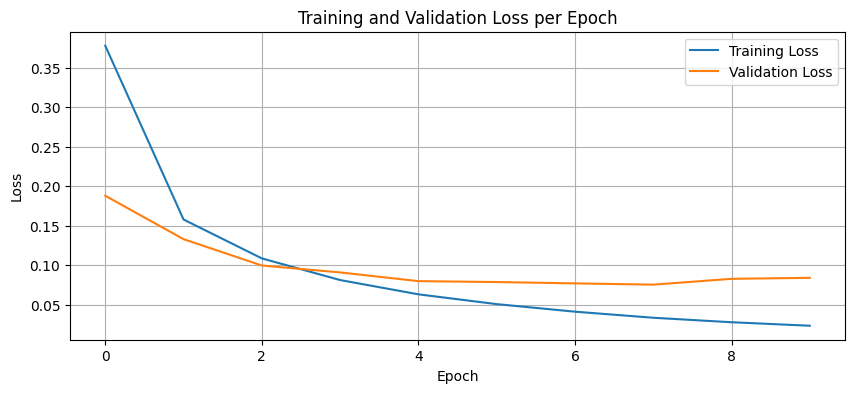

In [27]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Training Loss')
plt.plot(test_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss per Epoch')
plt.legend()
plt.grid(True)
plt.show()

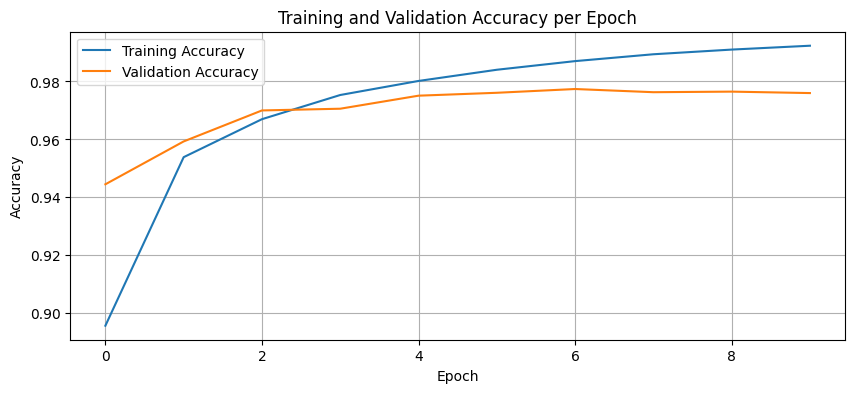

In [19]:
plt.figure(figsize=(10, 4))
plt.plot(train_acc, label='Training Accuracy')
plt.plot(test_acc, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy per Epoch')
plt.legend()
plt.grid(True)
plt.show()

### 5.2 Interpretation of Loss and Accuracy Curves

These plots are crucial for understanding how well our model is learning and generalizing:

#### Loss Curves (Training Loss vs. Validation Loss):

-   **Decreasing Trend**: Ideally, both training and validation loss should decrease over epochs, indicating that the model is learning from the data and fitting the patterns.
-   **Gap between Curves**: A significant and growing gap between the training loss and validation loss often indicates **overfitting**. This means the model is learning the training data too well, including its noise, and is not generalizing effectively to unseen validation data.
-   **Plateau/Increase in Validation Loss**: If the validation loss stops decreasing or starts to increase while training loss continues to decrease, it's a strong sign of overfitting.

In our plots, we observe that both training and validation losses decrease steadily, suggesting the model is learning. The validation loss is slightly higher but follows a similar trend to the training loss, which is expected for unseen data.

#### Accuracy Curves (Training Accuracy vs. Validation Accuracy):

-   **Increasing Trend**: Both training and validation accuracy should ideally increase over epochs, signifying that the model is making more correct predictions.
-   **Gap between Curves**: Similar to loss, a widening gap where training accuracy is much higher than validation accuracy points to **overfitting**. The model performs exceptionally well on the data it has seen but struggles with new data.
-   **Plateau/Stagnation in Validation Accuracy**: If validation accuracy plateaus or fluctuates significantly while training accuracy continues to rise, it suggests that further training might lead to overfitting.

For our model, both training and validation accuracies increase over epochs, indicating good learning. The validation accuracy closely tracks the training accuracy, which is a positive sign for generalization. The slight difference is normal, as the validation set represents unseen data.

### 5.3 Final Test Set Evaluation

After training, it's crucial to evaluate the model's performance on a completely **unseen** test set. This gives us an unbiased estimate of how well our model generalizes to new data.

-   `test_load_all = DataLoader(test_data, batch_size=10000, shuffle=False)`: We create a DataLoader for the entire test set, loading all samples in one batch. This is acceptable for evaluation as we don't need to perform batch-wise gradient updates.
-   `with torch.no_grad():`: As with validation during training, we disable gradient calculations for the final test evaluation to save computational resources.
-   The loop iterates through the single batch of test data:
    -   `y_val = model(x_test.view(len(x_test), -1))`: The test images are passed through the trained model.
    -   `predicted = torch.max(y_val, 1)[1]`: The class with the highest log-probability is selected as the model's prediction.
    -   `correct += (y_test == predicted).sum()`: We sum the number of correctly predicted samples.
-   `acc_test = correct.item() / len(test_data)`: The final test accuracy is calculated by dividing the total correct predictions by the total number of samples in the test set.

In [20]:
test_load_all = DataLoader(test_data, batch_size=10000, shuffle=False)

with torch.no_grad():
    correct = 0

    for x_test, y_test in test_load_all:
       # Move data to the selected device
       x_test, y_test = x_test.to(device), y_test.to(device)

       y_val = model(x_test.view(len(x_test), -1))
       predicted = torch.max(y_val, 1)[1]
       correct += (y_test == predicted).sum()

acc_test = correct.item()/len(test_data)

In [21]:
acc_test

0.976

### 5.3 Confusion Matrix Analysis

A confusion matrix is a powerful tool for understanding the performance of a classification model. It shows not only where the model made correct predictions but also where it made mistakes (misclassifications) and what kind of mistakes they were.

-   `confusion_matrix(predicted.view(-1), y_test.view(-1))`: We use `sklearn.metrics.confusion_matrix` to generate the confusion matrix. It compares the model's `predicted` labels with the actual `y_test` labels.

#### Visualizing the Confusion Matrix with a Heatmap

To make the confusion matrix more interpretable, especially for 10 classes, we visualize it as a heatmap using `seaborn`:

-   `sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ...)`:
    -   `cm`: The confusion matrix computed previously.
    -   `annot=True`: Displays the actual numbers in each cell.
    -   `fmt='d'`: Formats the annotations as integers.
    -   `cmap='Blues'`: Uses a blue color map, where darker shades indicate higher values.
    -   `xticklabels`, `yticklabels`: Label the x and y axes with the digits 0-9 for clarity.
    -   `plt.xlabel`, `plt.ylabel`, `plt.title`: Add appropriate labels and a title to the plot.

This heatmap helps us quickly identify which digits are frequently confused by the model (e.g., are 3s often misclassified as 8s?). Ideally, the diagonal elements (correct predictions) should be high, and off-diagonal elements (misclassifications) should be low.

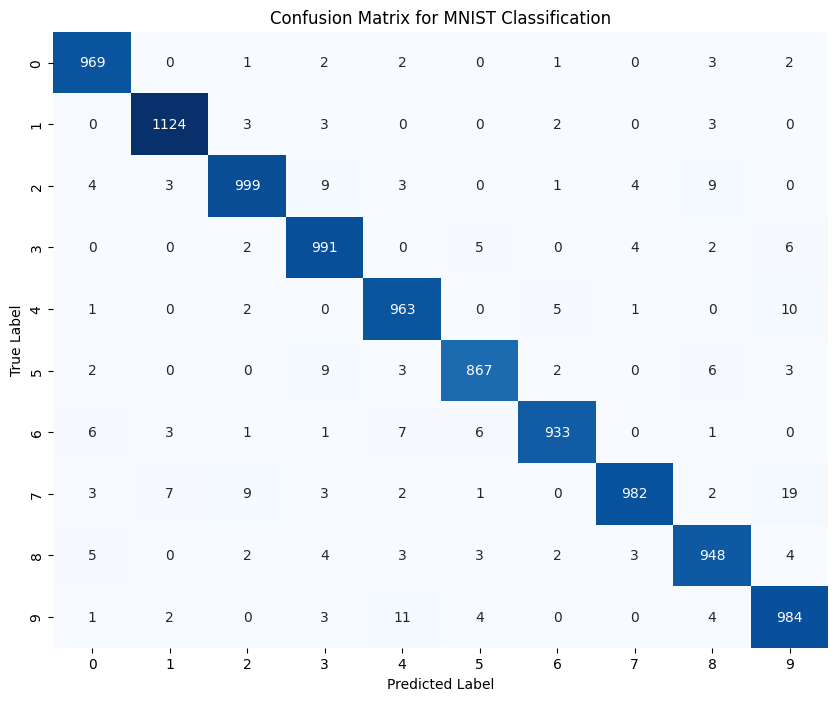

In [22]:
import seaborn as sns

# Assuming 'predicted' and 'y_test' are available from the previous cell
cm = confusion_matrix(y_test.cpu(), predicted.cpu())

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=np.arange(10), yticklabels=np.arange(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for MNIST Classification')
plt.show()

In MLP, flattening out the image ends up removing some of the 2d information, like the relationship of a pixel to its neighboring pixels

For now, we ignored it but we come back to it later when we discuss CNN.

## 6. Key PyTorch Training Concepts (Prerequisites)

It's essential to understand some fundamental PyTorch concepts and common patterns used in neural network training. This section explains specific functionalities that are crucial for understanding the subsequent training code.

### 6.1 Reshaping Inputs for the MLP (`.view()`)

Our `MultilayerPerceptron` model expects a flattened input vector (e.g., `784` features for a `28x28` image). However, the `DataLoader` provides images in a `(batch_size, num_channels, height, width)` format (e.g., `(100, 1, 28, 28)` for MNIST).

-   `tensor.view(dim1, dim2, ...)`: This method is used to reshape a tensor without changing its underlying data. It returns a new tensor with the specified dimensions, sharing the same data with the original tensor.
    -   `x_train.view(batch_size_train, -1)`:
        -   `batch_size_train`: We explicitly set the first dimension to the batch size (e.g., `100`).
        -   `-1`: PyTorch automatically infers the size of this dimension based on the original tensor's total number of elements. For a `(100, 1, 28, 28)` tensor, `-1` will result in `1 * 28 * 28 = 784`. Thus, the tensor is reshaped to `(100, 784)`, providing `100` flattened image vectors of `784` pixels each.

In [23]:
first_batch_images.shape

torch.Size([100, 1, 28, 28])

In [24]:
first_batch_images.view(100, -1)
# -1 will be itself calculate the second dim
# by 100 we specified the first dim

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

In [25]:
first_batch_images.view(100, -1).shape

torch.Size([100, 784])

In [29]:
#shape of the predicted labels of the first batch
model(first_batch_images.view(batch_size_train, -1).to(device)).shape

torch.Size([100, 10])

### 6.2 Understanding Model Outputs (`.data` vs. `.detach()` vs. `torch.no_grad()`)

When working with PyTorch tensors, especially model outputs, it's important to handle their relationship with the computation graph and gradients correctly. Misusing these can lead to subtle bugs or incorrect gradient calculations.

-   **`.data`**: Historically, `.data` was used to get the raw tensor data without tracking its computational history (gradients). **However, its use is generally discouraged because it can lead to subtle bugs, especially when working with PyTorch's autograd system.** Modifying a tensor obtained via `.data` in-place will modify the original tensor but won't be recorded by autograd, leading to incorrect gradients.

-   **`.detach()`**: If you need to perform an operation on a tensor without tracking its gradients, but still want to be safe, use `.detach()`. This creates a *new* tensor that shares the same data as the original but is *detached* from the computation graph. Modifications to the detached tensor will *not* affect the original tensor's gradients, and gradients will not be propagated back to the detached tensor.

-   **`with torch.no_grad():` block**: If you want to perform several operations without tracking gradients (e.g., during evaluation, testing, or when visualizing results), wrap them in a `with torch.no_grad():` block. This context manager temporarily disables gradient tracking for all operations within its scope, which saves memory and computation. This is the preferred way to handle operations where gradients are not needed.

In [30]:
p = model(first_batch_images.view(batch_size_train, -1).to(device))
p

tensor([[-5.7724e+00,  1.2752e+00,  1.1532e+01, -1.0992e+00, -1.9102e+01,
         -7.0057e+00, -1.7433e+01,  9.2184e+00, -9.5949e+00, -1.4782e+01],
        [-1.7620e+01, -3.3755e+00,  1.3281e+01,  2.5822e+00, -1.3109e+01,
         -1.2289e+01, -1.8759e+01, -7.2920e-01,  8.6609e-01, -1.7603e+01],
        [-1.0852e+01, -7.2979e+00, -3.2915e+00,  1.5666e+01, -1.4935e+01,
         -2.9118e+00, -2.3956e+01, -7.4323e+00, -1.3817e+00, -2.6030e+00],
        [-7.3930e+00, -5.6354e+00, -1.0992e+01,  3.1067e+00, -1.0741e+01,
          1.4317e+01, -2.8221e+00, -1.1206e+01, -1.8565e+00, -4.9318e+00],
        [-1.0847e+01, -8.5967e+00, -2.7140e+00, -1.4218e+00, -7.7241e+00,
         -9.1180e+00, -1.2338e+01, -1.1182e+01,  1.0506e+01, -3.7627e+00],
        [-1.9612e+01, -1.2046e+01, -1.5975e+01,  3.2373e+00, -1.8147e+01,
          1.5853e+01, -1.1499e+01, -1.8673e+01,  2.2757e+00,  1.0629e+00],
        [-1.6724e+01, -5.5681e+00, -2.9485e+00,  1.7049e+01, -2.1225e+01,
         -1.5633e+00, -2.8303e+0

In [31]:
p.data

tensor([[-5.7724e+00,  1.2752e+00,  1.1532e+01, -1.0992e+00, -1.9102e+01,
         -7.0057e+00, -1.7433e+01,  9.2184e+00, -9.5949e+00, -1.4782e+01],
        [-1.7620e+01, -3.3755e+00,  1.3281e+01,  2.5822e+00, -1.3109e+01,
         -1.2289e+01, -1.8759e+01, -7.2920e-01,  8.6609e-01, -1.7603e+01],
        [-1.0852e+01, -7.2979e+00, -3.2915e+00,  1.5666e+01, -1.4935e+01,
         -2.9118e+00, -2.3956e+01, -7.4323e+00, -1.3817e+00, -2.6030e+00],
        [-7.3930e+00, -5.6354e+00, -1.0992e+01,  3.1067e+00, -1.0741e+01,
          1.4317e+01, -2.8221e+00, -1.1206e+01, -1.8565e+00, -4.9318e+00],
        [-1.0847e+01, -8.5967e+00, -2.7140e+00, -1.4218e+00, -7.7241e+00,
         -9.1180e+00, -1.2338e+01, -1.1182e+01,  1.0506e+01, -3.7627e+00],
        [-1.9612e+01, -1.2046e+01, -1.5975e+01,  3.2373e+00, -1.8147e+01,
          1.5853e+01, -1.1499e+01, -1.8673e+01,  2.2757e+00,  1.0629e+00],
        [-1.6724e+01, -5.5681e+00, -2.9485e+00,  1.7049e+01, -2.1225e+01,
         -1.5633e+00, -2.8303e+0

In [32]:
p.detach()

tensor([[-5.7724e+00,  1.2752e+00,  1.1532e+01, -1.0992e+00, -1.9102e+01,
         -7.0057e+00, -1.7433e+01,  9.2184e+00, -9.5949e+00, -1.4782e+01],
        [-1.7620e+01, -3.3755e+00,  1.3281e+01,  2.5822e+00, -1.3109e+01,
         -1.2289e+01, -1.8759e+01, -7.2920e-01,  8.6609e-01, -1.7603e+01],
        [-1.0852e+01, -7.2979e+00, -3.2915e+00,  1.5666e+01, -1.4935e+01,
         -2.9118e+00, -2.3956e+01, -7.4323e+00, -1.3817e+00, -2.6030e+00],
        [-7.3930e+00, -5.6354e+00, -1.0992e+01,  3.1067e+00, -1.0741e+01,
          1.4317e+01, -2.8221e+00, -1.1206e+01, -1.8565e+00, -4.9318e+00],
        [-1.0847e+01, -8.5967e+00, -2.7140e+00, -1.4218e+00, -7.7241e+00,
         -9.1180e+00, -1.2338e+01, -1.1182e+01,  1.0506e+01, -3.7627e+00],
        [-1.9612e+01, -1.2046e+01, -1.5975e+01,  3.2373e+00, -1.8147e+01,
          1.5853e+01, -1.1499e+01, -1.8673e+01,  2.2757e+00,  1.0629e+00],
        [-1.6724e+01, -5.5681e+00, -2.9485e+00,  1.7049e+01, -2.1225e+01,
         -1.5633e+00, -2.8303e+0

so .data just captures the data (without grad_fn=<LogSoftmaxBackward0>)

### 6.3 Converting Model Probabilities to Predicted Labels

Our `MultilayerPerceptron` returns log-probabilities for each class (10 classes for MNIST) via `F.log_softmax` in its `forward` method. To get the actual predicted class label (an integer from 0 to 9), we need to find the index corresponding to the highest log-probability.

-   `torch.max(input, dim)`:
    -   `input`: The tensor containing the log-probabilities (e.g., `p` from `model(x_train)`), which has a shape like `(batch_size, num_classes)`.
    -   `dim=1`: Specifies that the `max` operation should be performed along dimension `1` (the class dimension) for each sample in the batch.
    -   This function returns a tuple: `(values, indices)`. `values` are the maximum log-probabilities, and `indices` are the corresponding class labels.

-   `.indices`: We only care about the `indices` (the predicted class labels), so we access the second element of the tuple returned by `torch.max`.

In [34]:
torch.max(p, 1).indices #or torch.max(p, 1)[1]

tensor([2, 2, 3, 5, 8, 5, 3, 6, 9, 9, 1, 3, 5, 5, 4, 5, 4, 1, 0, 4, 5, 4, 5, 4,
        0, 5, 8, 2, 2, 3, 3, 7, 2, 8, 1, 2, 3, 1, 7, 9, 0, 4, 9, 1, 7, 9, 7, 2,
        6, 5, 5, 8, 5, 0, 4, 0, 0, 4, 9, 2, 6, 0, 8, 4, 1, 8, 5, 2, 0, 3, 3, 4,
        6, 1, 5, 3, 5, 9, 0, 7, 4, 5, 3, 6, 6, 4, 5, 3, 9, 7, 1, 7, 6, 7, 9, 3,
        5, 9, 9, 6], device='cuda:0')

### 6.4 Extracting Scalar Values (`.item()`)

When you have a PyTorch tensor that contains only a single scalar value (e.g., a loss value), you often need to convert it to a standard Python number for operations like printing, storing in a list, or using in standard Python arithmetic. The `.item()` method serves this purpose.

-   `tensor.item()`: This method extracts the Python number from a tensor that holds a single element. It detaches the tensor from the computation graph and returns its value as a standard Python `float` or `int`.

-   **Why not just `tensor`?**: While `print(tensor)` works, `tensor.item()` gives you the raw numeric value, which is often more convenient for calculations or logging, especially when you don't need the tensor's metadata or gradient tracking for that specific value.

<a id='section7'></a>
### 6.5 General Python Formatting (F-strings)

F-strings (formatted string literals) in Python provide a concise and readable way to embed expressions inside string literals. They are prefixed with an `f` or `F` and use curly braces `{}` to contain expressions that will be replaced with their values.

### Formatting Floating-Point Numbers with F-strings

When displaying floating-point numbers, especially in tables or logs, it's often desirable to control their precision and alignment. F-strings offer powerful mini-language specifications for this:

-   `{value:width.precisionf}`:
    -   `value`: The floating-point variable you want to format.
    -   `:`: Separates the value from the format specifier.
    -   `width`: An optional integer that specifies the *minimum total width* of the output string. If the formatted number is shorter than this width, it will be padded with spaces to the left. If the number is longer, this specification is ignored, and the full number is displayed.
    -   `.precision`: An integer that specifies the *number of digits to display after the decimal point*.
    -   `f`: Indicates that the value should be formatted as a fixed-point floating-point number.

**Examples:**

-   `'{value:10.8f}'`: Formats `value` as a float with `8` digits after the decimal point, ensuring a minimum total width of `10` characters. This means the decimal point and any digits before it count towards the width.
-   `'{value:7.4f}'`: Formats `value` as a float with `4` digits after the decimal point, with a minimum total width of `7` characters.

In [36]:
value1 = 3.14159265
value2 = 1234.56
value3 = 0.5

print(f"Value 1 (10.8f): '{value1:10.8f}'")
print(f"Value 1 (7.4f):  '{value1:7.4f}'")
print(f"Value 2 (10.8f): '{value2:10.8f}'")
print(f"Value 2 (7.4f):  '{value2:7.4f}'")
print(f"Value 3 (10.8f): '{value3:10.8f}'")
print(f"Value 3 (7.4f):  '{value3:7.4f}'")

Value 1 (10.8f): '3.14159265'
Value 1 (7.4f):  ' 3.1416'
Value 2 (10.8f): '1234.56000000'
Value 2 (7.4f):  '1234.5600'
Value 3 (10.8f): '0.50000000'
Value 3 (7.4f):  ' 0.5000'


```
Output Explanation:

'{value1:10.8f}': The number 3.14159265 has 8 digits after the decimal. With the decimal point and the leading 3, it's 10 characters long (3.14159265). Since the specified total width is 10, no extra padding is added.
'{value1:7.4f}': The number 3.14159265 is rounded to 3.1416 (4 decimal places). This string is 6 characters long (3.1416). Since the specified total width is 7, one space is added to the left to make it 3.1416.
'{value2:10.8f}': The number 1234.56 needs 8 decimal places, so it becomes 1234.56000000. This string is 13 characters long. Since the specified width 10 is smaller than the required width, the width specifier is ignored, and the full number is printed.
'{value2:7.4f}': The number 1234.56 becomes 1234.5600 (4 decimal places). This string is 9 characters long. Again, since the specified width 7 is smaller, the full number is printed.
'{value3:10.8f}': The number 0.5 becomes 0.50000000 (8 decimal places). This is 10 characters long. No padding is added.
'{value3:7.4f}': The number 0.5 becomes 0.5000 (4 decimal places). This is 6 characters long. Since the specified width is 7, one space is added to the left to make it 0.5000.
In essence, 10 or 7 sets a minimum column width, which can help align numbers in tabular output, but it won't truncate numbers if they naturally exceed that width due to their value or precision.

```